# 13 · Density nowcasts

A point nowcast of 0.2 % means very different things if the uncertainty around it is
±0.3 or ±1.5 percentage points. Central banks increasingly communicate fan charts, and
forecast evaluation has moved from point accuracy to **proper scoring rules** for
whole distributions (Gneiting & Raftery, 2007). `nowcastbox` produces density nowcasts
(innovation I5) from two sources of uncertainty:

* **filtering uncertainty** — given the parameters, the Kalman smoother delivers the
  conditional variance of the target; it shrinks as data arrive;
* **parameter uncertainty** — estimated by bootstrap with re-estimation, either
  *parametric* (simulate the fitted state-space model) or *block* (resample blocks of
  the panel), and combined into a Gaussian mixture.

Densities are evaluated with the **CRPS** (continuous ranked probability score), the
**log score**, the **PIT** (probability integral transform: if the densities are
correct, the PIT values are uniform), interval **coverage** tests (Christoffersen,
1998) and the **Berkowitz** (2001) test.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from utils import SEED, brazil_panel, display, md, pct, setup, show

import nowcastbox as nb
from nowcastbox import scoring

setup()

## 1. One nowcast, three densities

The compact Brazilian panel on raw (not winsorised) data, vintage of 15 September
2026, target 2026Q3.

In [2]:
ds, panel = brazil_panel(start="2005-01", replace_outliers=False)
calendar = nb.load_brazil_calendar()
vintage = nb.pseudo_real_time(panel, calendar=calendar, vintage="2026-09-15")
model = nb.MixedFreqDFM(n_factors=1, factor_lags=1, tol=1e-3)
res = model.fit(vintage, target="pib")
target = pd.Period("2026Q3", "Q")

gaussian = res.distribution()  # filtering uncertainty only
parametric = res.distribution(n_boot=20, method="parametric", periods=[target], random_state=SEED)
block = res.distribution(n_boot=20, method="block", periods=[target], random_state=SEED)
table = pd.DataFrame(
    {
        name: {
            "mean": pct(d.mean.loc[target]),
            "std (pp)": round(100 * d.std.loc[target], 3),
            "90% interval": " to ".join(pct(v) for v in d.interval(0.9).loc[target]),
        }
        for name, d in (
            ("Gaussian", gaussian),
            ("parametric bootstrap", parametric),
            ("block bootstrap", block),
        )
    }
).T
display(table)
display(block.variance_decomposition.loc[[target]].rename(index=str))

,mean,std (pp),90% interval
Gaussian,0.05%,0.894,-1.42% to 1.52%
parametric bootstrap,0.05%,0.859,-1.37% to 1.46%
block bootstrap,0.05%,1.021,-1.65% to 1.70%


,filtering,parameter,total
period,,,
2026Q3,0.0001,7.4807e-07,0.0001


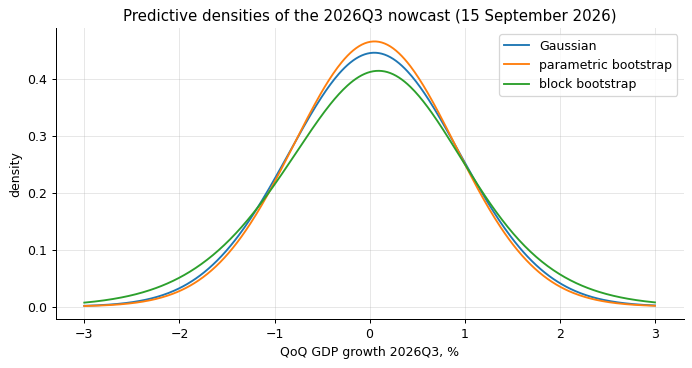

In [3]:
grid = np.linspace(-0.03, 0.03, 400)
fig, ax = plt.subplots()
for name, d in (
    ("Gaussian", gaussian),
    ("parametric bootstrap", parametric),
    ("block bootstrap", block),
):
    one = d.select([target])
    ax.plot(100 * grid, np.asarray(one.pdf(grid)).ravel() / 100, label=name)
ax.set_xlabel("QoQ GDP growth 2026Q3, %")
ax.set_ylabel("density")
ax.set_title("Predictive densities of the 2026Q3 nowcast (15 September 2026)")
ax.legend()
show(fig, "13_densities")

For this model and sample, **filtering uncertainty dominates**: re-estimating the
parameters on bootstrap samples adds little variance (see the decomposition), so the
three densities are close. The block bootstrap, which also resamples the data, is the
widest. Parameter uncertainty matters more in short samples, with many factors, or
right after a structural break.

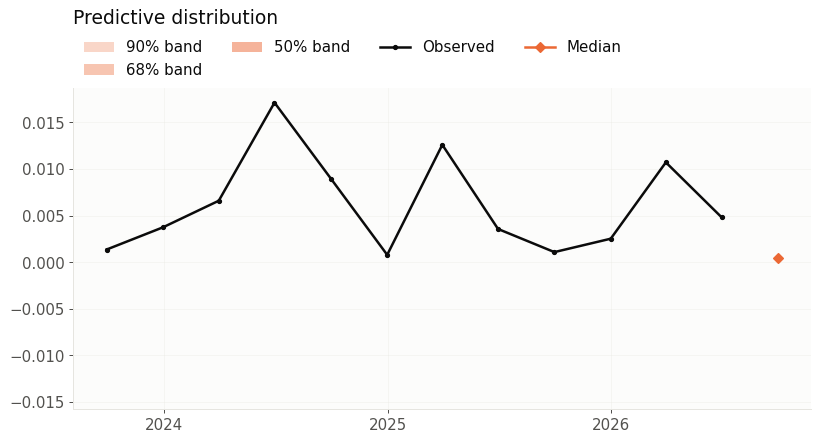

In [4]:
fig = res.plot("fan", backend="matplotlib")
show(fig, "13_fan")

## 2. Are the densities calibrated? 2012–2025

For every quarter from 2012Q1 to 2025Q4 we take the vintage of the 15th of its last
month, estimate the model and keep the predictive mean and standard deviation of that
quarter (`months_to_end = 0`). Two competitors:

* the **two-step** DFM (bridge-equation uncertainty plus filtering);
* a **climatological** density: normal with the mean and standard deviation of GDP
  growth published up to the vintage — what one would say without any monthly data.

Realisations are the published growth rates (latest vintage).

In [5]:
published = nb.apply_transforms(ds.data, ds.transform).to_native("pib")
rows = []
for q in pd.period_range("2012Q1", "2025Q4", freq="Q"):
    date = q.asfreq("M", "end").to_timestamp() + pd.Timedelta(days=14)
    data = nb.pseudo_real_time(panel, calendar=calendar, vintage=date)
    em = model.fit(data, target="pib").nowcast.loc[q]
    two = nb.TwoStepDFM(n_factors=2, factor_lags=1).fit(data, target="pib").nowcast.loc[q]
    history = data.to_native("pib").dropna()
    rows.append(
        {
            "quarter": q,
            "EM DFM": (em["out_of_sample"], em["std"]),
            "two-step DFM": (two["out_of_sample"], two["std"]),
            "climatology": (history.mean(), history.std()),
            "actual": published.loc[q],
        }
    )
dens = pd.DataFrame(rows).set_index("quarter")
md(f"{len(dens)} quarterly density nowcasts per model.")

56 quarterly density nowcasts per model.

In [6]:
models = ["EM DFM", "two-step DFM", "climatology"]


def scores(frame: pd.DataFrame) -> pd.DataFrame:
    """Average scores, coverage and calibration tests of each model on ``frame``."""
    y = frame["actual"].to_numpy()
    out = {}
    for m in models:
        mu = np.array([v[0] for v in frame[m]])
        sd = np.array([v[1] for v in frame[m]])
        pit_values = norm.cdf(y, mu, sd)  # PIT of a Gaussian density
        hits90 = scoring.interval_hits(y, mu - 1.645 * sd, mu + 1.645 * sd)
        out[m] = {
            "CRPS (pp)": 100 * float(np.mean(scoring.crps_gaussian(y, mu, sd))),
            "log score": float(np.mean(scoring.log_score_gaussian(y, mu, sd))),
            "coverage 68%": scoring.interval_coverage(y, mu - sd, mu + sd),
            "coverage 90%": float(np.mean(hits90)),
            "Christoffersen 90% p (cc)": scoring.christoffersen_test(hits90, 0.9).pvalue_cc,
            "Berkowitz p": scoring.berkowitz_test(pit_values).pvalue,
        }
    return pd.DataFrame(out).T


pandemic = pd.period_range("2020Q1", "2021Q1", freq="Q")
display(
    pd.concat(
        {"2012-2025": scores(dens), "excluding 2020Q1-2021Q1": scores(dens.drop(pandemic))}, axis=1
    ).T.round(3)
)

EM DFM  two-step DFM  climatology
2012-2025               CRPS (pp)                   0.668         0.550        0.907
                        log score                   2.756         2.896        2.294
                        coverage 68%                0.786         0.714        0.804
                        coverage 90%                0.875         0.821        0.857
                        Christoffersen 90% p (cc)   0.044         0.149        0.008
                        Berkowitz p                 0.000         0.001        0.005
excluding 2020Q1-2021Q1 CRPS (pp)                   0.434         0.429        0.599
                        log score                   3.379         3.411        3.008
                        coverage 68%                0.843         0.745        0.863
                        coverage 90%                0.922         0.843        0.922
                        Christoffersen 90% p (cc)   0.363         0.097        0.363
                        Berkowitz p                 0.046         0.047        0.000

Lower CRPS is better; the log score is the average log predictive density (higher is
better here, as returned by `log_score_gaussian`; check the sign convention of your
reporting standard).

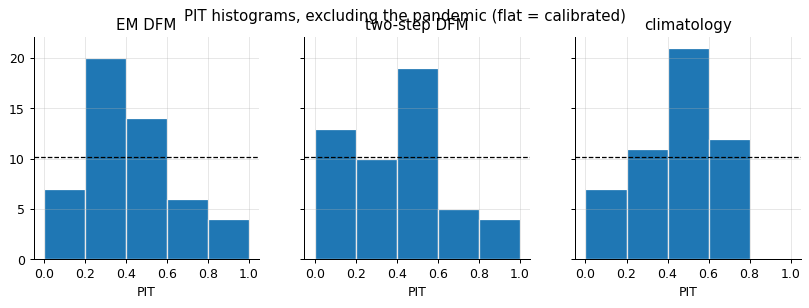

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
calm = dens.drop(pandemic)
for ax, m in zip(axes, models, strict=True):
    mu = np.array([v[0] for v in calm[m]])
    sd = np.array([v[1] for v in calm[m]])
    ax.hist(norm.cdf(calm["actual"], mu, sd), bins=np.linspace(0, 1, 6), edgecolor="white")
    ax.axhline(len(calm) / 5, color="k", ls="--", lw=1)
    ax.set_title(m)
    ax.set_xlabel("PIT")
fig.suptitle("PIT histograms, excluding the pandemic (flat = calibrated)")
show(fig, "13_pit")

**Reading.**

* **Sharpness.** The monthly data make the densities much more informative: both
  DFMs have a CRPS 25–40 % below the climatological density and a higher log score.
  Over the full window the two-step model scores best; outside the pandemic the two
  DFMs are equivalent.
* **Calibration in normal times.** Excluding 2020Q1–2021Q1, the EM densities are
  slightly *too wide*: 84 % of outcomes fall in the nominal 68 % band and 92 % in the
  90 % band (the Christoffersen test does not reject at 90 %, Berkowitz rejects at
  5 %; the PIT histogram is hump-shaped). Estimated on raw data, the model inflates
  the idiosyncratic variance of GDP to accommodate 2020, and that variance enters every
  later band. The two-step model, whose uncertainty comes from the bridge regression,
  is closer to nominal at 68 % and slightly narrow at 90 %.
* **The pandemic** quarters fall far outside any Gaussian band and dominate the
  full-sample tests (all reject).

Remedies available in `nowcastbox`: robust estimation (Student-t errors or COVID
dummies, notebook 10) so that 2020 does not inflate the variances, the bootstrap for
parameter uncertainty, and empirical recalibration of the bands from backtest errors.

### References

* Berkowitz, J. (2001). Testing density forecasts, with applications to risk
  management. *JBES*, 19(4), 465–474.
* Christoffersen, P. F. (1998). Evaluating interval forecasts. *International
  Economic Review*, 39(4), 841–862.
* Diebold, F. X., Gunther, T. A. & Tay, A. S. (1998). Evaluating density forecasts.
  *International Economic Review*, 39(4), 863–883.
* Gneiting, T. & Raftery, A. E. (2007). Strictly proper scoring rules, prediction, and
  estimation. *JASA*, 102(477), 359–378.
* Aastveit, K. A., Gerdrup, K. R., Jore, A. S. & Thorsrud, L. A. (2014). Nowcasting
  GDP in real time: a density combination approach. *JBES*, 32(1), 48–68.